# Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,r2_score

# Load Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/muhammadwaqas023/ai-impact-in-future-on-jobs-market-in-2030/AI_Impact_on_Jobs_2030.csv')

df.head()

,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,AIJ-100000,Data Engineer,Healthcare,Japan,PhD,1,0.25,0.78,Yes,207392,"Python, Communication, Deep Learning",Low,3,37,Enterprise,High,2.08,Yes,3.86,Growing
1,AIJ-100001,Healthcare Analyst,Retail,UK,Bachelor,24,0.73,0.33,No,140785,"Deep Learning, Azure, Communication, TensorFlo...",Low,-5,42,Startup,Moderate,4.54,No,4.23,Growing
2,AIJ-100002,HR Specialist,Education,Canada,High School,21,0.80,0.69,Yes,124800,"Kubernetes, Cloud Computing, TensorFlow, SQL, ...",Medium,-5,57,Startup,Low,3.14,No,3.54,Stable
3,AIJ-100003,Cybersecurity Analyst,Government,UK,Bachelor,5,0.29,0.94,No,199878,"Excel, Kubernetes, Prompt Engineering, Leadership",Medium,7,59,Enterprise,High,3.67,No,4.37,Declining
4,AIJ-100004,Healthcare Analyst,Education,UAE,PhD,20,0.11,0.92,No,178682,"SQL, Leadership, TensorFlow, Cybersecurity",Low,6,34,Startup,High,3.68,No,3.99,Stable


# Basic Information

In [3]:
df.shape



(3000, 20)

In [4]:
df.describe()

,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Average_Salary_USD,Job_Growth_2030,Work_Hours_Per_Week,Performance_Score,Job_Satisfaction
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,12.383000,0.502910,0.601203,126641.746667,17.238333,44.773333,3.514643,3.026167
std,7.528958,0.261293,0.226674,55405.053057,16.230322,8.926469,0.873375,1.146361
min,0.000000,0.050000,0.200000,30221.000000,-10.000000,30.000000,2.000000,1.000000
25%,6.000000,0.280000,0.420000,77262.000000,3.000000,37.000000,2.760000,2.060000
50%,12.000000,0.500000,0.600000,127660.500000,17.000000,45.000000,3.540000,3.025000
75%,19.000000,0.730000,0.800000,174811.750000,31.000000,52.000000,4.270000,4.010000
max,25.000000,0.950000,0.990000,219998.000000,45.000000,60.000000,5.000000,5.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Employee_ID              3000 non-null   object 
 1   Job_Title                3000 non-null   object 
 2   Industry                 3000 non-null   object 
 3   Country                  3000 non-null   object 
 4   Education_Level          3000 non-null   object 
 5   Years_Experience         3000 non-null   int64  
 6   AI_Replacement_Risk      3000 non-null   float64
 7   Future_Demand_Score      3000 non-null   float64
 8   Remote_Work_Possibility  3000 non-null   object 
 9   Average_Salary_USD       3000 non-null   int64  
 10  Required_Skills          3000 non-null   object 
 11  Automation_Level         3000 non-null   object 
 12  Job_Growth_2030          3000 non-null   int64  
 13  Work_Hours_Per_Week      3000 non-null   int64  
 14  Company_Size            

In [6]:
df.isnull().sum().to_frame(name='Missing Values')


,Missing Values
Employee_ID,0
Job_Title,0
Industry,0
Country,0
Education_Level,0
Years_Experience,0
AI_Replacement_Risk,0
Future_Demand_Score,0
Remote_Work_Possibility,0
Average_Salary_USD,0


In [7]:
df.duplicated().to_frame(name='Duplicated ')


,Duplicated
0,False
1,False
2,False
3,False
4,False
...,...
2995,False
2996,False
2997,False
2998,False


In [8]:
df.nunique().to_frame(name='Unique Counts')


,Unique Counts
Employee_ID,3000
Job_Title,20
Industry,10
Country,10
Education_Level,4
Years_Experience,26
AI_Replacement_Risk,91
Future_Demand_Score,80
Remote_Work_Possibility,3
Average_Salary_USD,2970


In [9]:
df.select_dtypes(include=['int64', 'float64']).corr()


,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Average_Salary_USD,Job_Growth_2030,Work_Hours_Per_Week,Performance_Score,Job_Satisfaction
Years_Experience,1.000000,-0.033668,-0.047494,0.012795,-0.023781,-0.010387,0.023758,0.018071
AI_Replacement_Risk,-0.033668,1.000000,0.007761,-0.006714,0.004887,0.001582,-0.012806,0.016181
Future_Demand_Score,-0.047494,0.007761,1.000000,0.005162,0.054455,-0.004530,0.018239,0.012901
Average_Salary_USD,0.012795,-0.006714,0.005162,1.000000,-0.011723,-0.012034,-0.009519,0.017736
Job_Growth_2030,-0.023781,0.004887,0.054455,-0.011723,1.000000,0.001496,-0.011879,0.001757
Work_Hours_Per_Week,-0.010387,0.001582,-0.004530,-0.012034,0.001496,1.000000,0.020974,0.014921
Performance_Score,0.023758,-0.012806,0.018239,-0.009519,-0.011879,0.020974,1.000000,-0.013037
Job_Satisfaction,0.018071,0.016181,0.012901,0.017736,0.001757,0.014921,-0.013037,1.000000


# Exploratory Data Analysis (EDA)

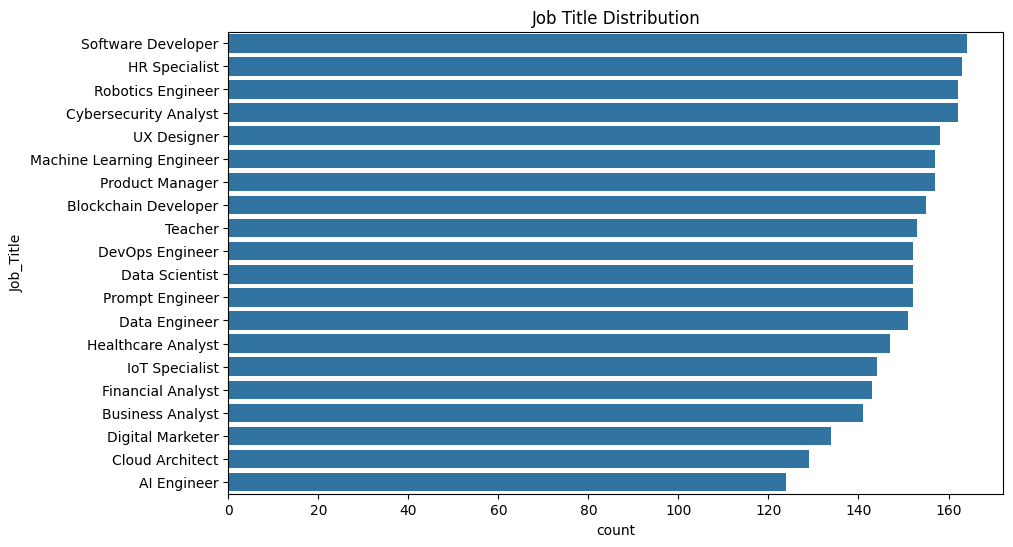

In [10]:
plt.figure(figsize=(10,6))
sns.countplot(
    y='Job_Title',
    data=df,
    order=df['Job_Title'].value_counts().index
)
plt.title("Job Title Distribution")
plt.show()

In [11]:
import plotly.io as pio
pio.renderers.default = "iframe_connected"
fig = px.histogram(
    df,
    x='Industry',
    color='Industry',
    title='Industry Distribution'
)

fig.show()

In [12]:
pio.renderers.default = "iframe_connected"
fig = px.pie(
    df,
    names='Country',
    title='Country Distribution'
)

fig.show()

In [13]:
pio.renderers.default = "iframe_connected"
fig = px.bar(
    df['Education_Level'].value_counts().reset_index(),
    x='Education_Level',
    y='count',
    title='Education Level'
)

fig.show()

In [14]:
pio.renderers.default = "iframe_connected"

fig = px.histogram(
    df,
    x='Average_Salary_USD',
    nbins=30,
    title='Salary Distribution'
)

fig.show()

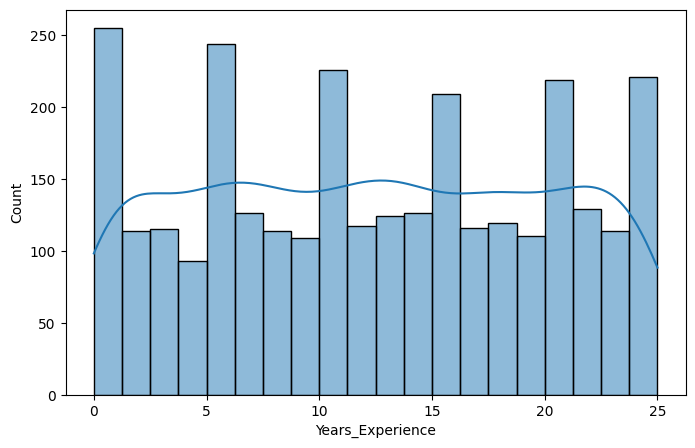

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Years_Experience'],
    bins=20,
    kde=True
)

plt.show()

In [16]:
pio.renderers.default = "iframe_connected"
fig = px.box(
    df,
    y='Future_Demand_Score'
)

fig.show()

In [17]:
pio.renderers.default = "iframe_connected"
fig = px.bar(
    df['Automation_Level'].value_counts().reset_index(),
    x='Automation_Level',
    y='count',
    color='Automation_Level'
)

fig.show()

In [18]:
pio.renderers.default = "iframe_connected"
fig = px.pie(
    df,
    names='Company_Size'
)

fig.show()

In [19]:
pio.renderers.default = "iframe_connected"
fig = px.bar(
    df['Hiring_Trend_2026'].value_counts().reset_index(),
    x='Hiring_Trend_2026',
    y='count',
    color='Hiring_Trend_2026'
)

fig.show()

In [20]:
pio.renderers.default = "iframe_connected"
fig = px.scatter(
    df,
    x='AI_Replacement_Risk',
    y='Future_Demand_Score',
    color='Automation_Level'
)

fig.show()

In [21]:
pio.renderers.default = "iframe_connected"
fig = px.box(
    df,
    x='Education_Level',
    y='Average_Salary_USD',
    color='Education_Level'
)

fig.show()

# Feature Engineering

In [22]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Model Building

In [23]:
y = df['Job_Growth_2030']

X = df.drop('Job_Growth_2030',axis=1)

In [24]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = RandomForestRegressor(
    random_state=42
)

model.fit(X_train,y_train)

pred = model.predict(X_test)

In [25]:
print("MAE :",mean_absolute_error(y_test,pred))
print("R2 :",r2_score(y_test,pred))

MAE : 14.758866666666666
R2 : -0.04911662914494341


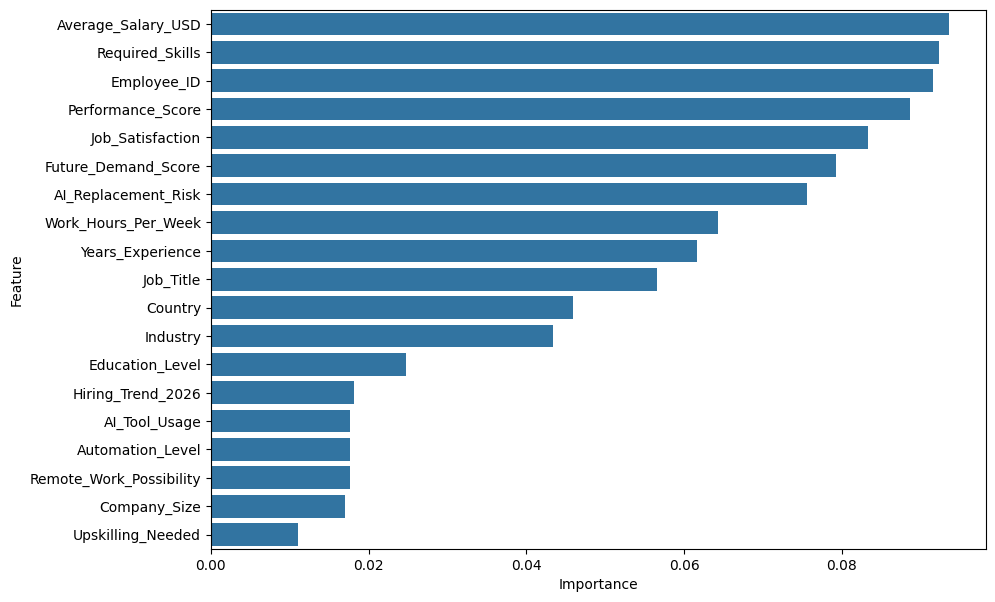

In [26]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':model.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

plt.figure(figsize=(10,7))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.show()